In [54]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from scipy.special import logit
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, Matern, DotProduct
import numpy as np
import matplotlib.pyplot as plt

In [30]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

class GaussianProcessWithPrior:
    def __init__(self, kernel=None, normalize_y=False, n_restarts_optimizer=10):
        self.gpr = GaussianProcessRegressor(kernel=kernel, normalize_y=normalize_y, n_restarts_optimizer=n_restarts_optimizer)
        self.train_prior = None  

    def fit(self, X, y, train_prior):
        """Fits the model to residuals (y - train_prior)."""
        if train_prior.shape != y.shape:
            raise ValueError("Shape mismatch between 'train_prior' and 'y'")
        self.train_prior = train_prior
        residuals = y - train_prior
        self.gpr.fit(X, residuals)

    def predict(self, X, predict_prior, return_std=True):
        """Predicts using the GP model with the prior added back."""
        if predict_prior.shape[0] != X.shape[0]:
            raise ValueError("Shape mismatch between 'predict_prior' and 'X'")

        mu, std = self.gpr.predict(X, return_std=True)
        mu_with_prior = mu + predict_prior

        if return_std:
            return sigmoid(mu_with_prior), std
        return sigmoid(mu_with_prior)

In [63]:
combined_df = pd.read_csv("combined_solidus_karma_results.csv", dtype={'Explanation': str})
combined_df

,Source,G,C,R,Vab,Prior,Truth,Explanation
0,Grid,100000.000000,0.15,0.012,0.408627,0,NaN,NaN
1,Grid,109854.114199,0.15,0.012,0.408627,0,NaN,NaN
2,Grid,120679.264064,0.15,0.012,0.408627,0,NaN,NaN
3,Grid,132571.136559,0.15,0.012,0.408627,0,NaN,NaN
4,Grid,145634.847750,0.15,0.012,0.408627,0,NaN,NaN
...,...,...,...,...,...,...,...,...
125048,Karma,100000.000000,0.19,0.030,0.630127,0,0.0,Cellular (not run)
125049,Karma,100000.000000,0.19,0.060,0.630127,0,0.0,Cellular (not run)
125050,Karma,100000.000000,0.19,0.120,0.630127,0,0.0,Cellular
125051,Karma,100000.000000,0.19,0.300,0.630127,0,0.0,Cellular (ish)


In [64]:
combined_df['log10(G)'] = np.log10(combined_df['G'])

In [65]:
combined_df

,Source,G,C,R,Vab,Prior,Truth,Explanation,log10(G)
0,Grid,100000.000000,0.15,0.012,0.408627,0,NaN,NaN,5.000000
1,Grid,109854.114199,0.15,0.012,0.408627,0,NaN,NaN,5.040816
2,Grid,120679.264064,0.15,0.012,0.408627,0,NaN,NaN,5.081633
3,Grid,132571.136559,0.15,0.012,0.408627,0,NaN,NaN,5.122449
4,Grid,145634.847750,0.15,0.012,0.408627,0,NaN,NaN,5.163265
...,...,...,...,...,...,...,...,...,...
125048,Karma,100000.000000,0.19,0.030,0.630127,0,0.0,Cellular (not run),5.000000
125049,Karma,100000.000000,0.19,0.060,0.630127,0,0.0,Cellular (not run),5.000000
125050,Karma,100000.000000,0.19,0.120,0.630127,0,0.0,Cellular,5.000000
125051,Karma,100000.000000,0.19,0.300,0.630127,0,0.0,Cellular (ish),5.000000


(array([26.,  7.,  4.,  3.,  2.,  2.,  2.,  1.,  1.,  2.]),
 array([  100000.,  1090000.,  2080000.,  3070000.,  4060000.,  5050000.,
         6040000.,  7030000.,  8020000.,  9010000., 10000000.]),
 <BarContainer object of 10 artists>)

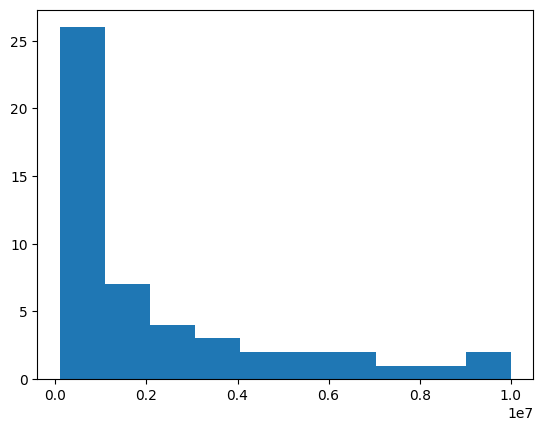

In [61]:
testlog2 = np.linspace(5,7)
testlog2 = 10**testlog2
plt.hist(testlog2)

(array([26.,  7.,  4.,  3.,  2.,  2.,  2.,  1.,  1.,  2.]),
 array([  100000.,  1090000.,  2080000.,  3070000.,  4060000.,  5050000.,
         6040000.,  7030000.,  8020000.,  9010000., 10000000.]),
 <BarContainer object of 10 artists>)

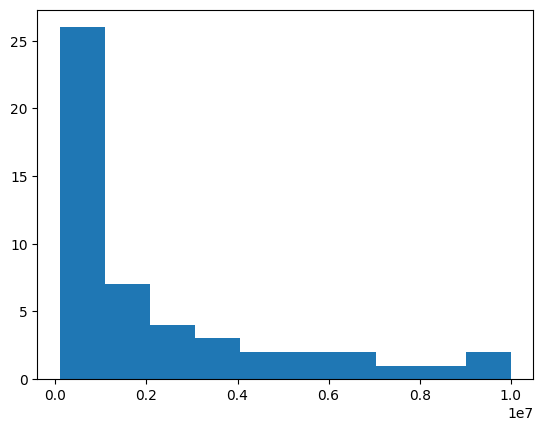

In [58]:
testlog = np.logspace(5,7)
plt.hist(testlog)

(array([12517., 12500., 12500., 12500., 12500., 12518., 12500., 12500.,
        12500., 12518.]),
 array([5. , 5.2, 5.4, 5.6, 5.8, 6. , 6.2, 6.4, 6.6, 6.8, 7. ]),
 <BarContainer object of 10 artists>)

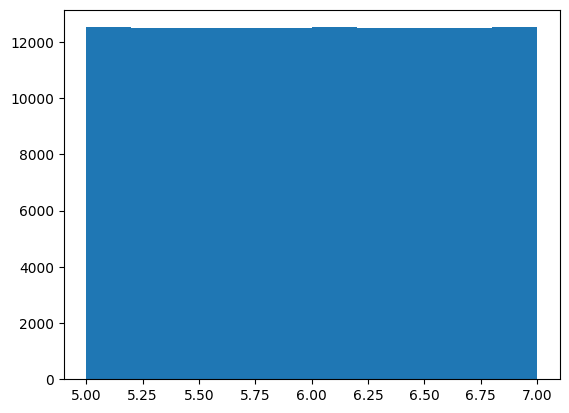

In [66]:
logG = combined_df['log10(G)'].values
plt.hist(logG)

In [31]:
combined_df = pd.read_csv("combined_solidus_karma_results.csv", dtype={'Explanation': str})
prior_scaler = MinMaxScaler(feature_range=(logit(.4), logit(.6)))
combined_df["Prior_Scaled"] = prior_scaler.fit_transform(combined_df[["Prior"]])
truth_scaler = MinMaxScaler(feature_range=(-5, 5))
combined_df["Truth_Scaled"] = truth_scaler.fit_transform(combined_df[["Truth"]])

train_df = (combined_df[combined_df["Source"] == "Karma"]).copy()
grid_df = (combined_df[combined_df["Source"] == "Grid"]).copy()

X_scaler = MinMaxScaler(feature_range=(0,1))
grid_df.loc[:,["R", "G", "C"]] = X_scaler.fit_transform(grid_df[["R", "G", "C"]])
train_df.loc[:,["R", "G", "C"]] = X_scaler.transform(train_df[["R", "G", "C"]])

X_train = train_df[["R", "G", "C"]].values
y_train = train_df["Truth_Scaled"].values
train_prior = train_df["Prior_Scaled"].values

In [37]:
gp = GaussianProcessWithPrior(kernel=Matern(nu=.5,length_scale=[1,1,1],length_scale_bounds=(.05,1)), n_restarts_optimizer=10,normalize_y=False)
gp.fit(X_train, y_train, train_prior)

In [39]:
gp.gpr.kernel_.length_scale

array([0.1756759 , 0.89638454, 0.87625045])

In [26]:
combined_df

,Source,G,C,R,Vab,Prior,Truth,Explanation,Prior_Scaled,Truth_Scaled
0,Grid,100000.000000,0.15,0.012,0.408627,0,NaN,NaN,-0.405465,NaN
1,Grid,302040.816327,0.15,0.012,0.408627,0,NaN,NaN,-0.405465,NaN
2,Grid,504081.632653,0.15,0.012,0.408627,0,NaN,NaN,-0.405465,NaN
3,Grid,706122.448980,0.15,0.012,0.408627,0,NaN,NaN,-0.405465,NaN
4,Grid,908163.265306,0.15,0.012,0.408627,0,NaN,NaN,-0.405465,NaN
...,...,...,...,...,...,...,...,...,...,...
125048,Karma,100000.000000,0.19,0.030,0.630127,0,0.0,Cellular (not run),-0.405465,-5.0
125049,Karma,100000.000000,0.19,0.060,0.630127,0,0.0,Cellular (not run),-0.405465,-5.0
125050,Karma,100000.000000,0.19,0.120,0.630127,0,0.0,Cellular,-0.405465,-5.0
125051,Karma,100000.000000,0.19,0.300,0.630127,0,0.0,Cellular (ish),-0.405465,-5.0


In [68]:
df_grid = pd.read_csv('grid_df_iteration_1.csv')
df_grid

,Source,G,C,R,Vab,Prior,Truth,Explanation,log10(G),Prior_Scaled,Truth_Scaled,Predicted_Probability,Std_Dev,H
0,Grid,1.000000e+05,0.15,0.012,0.408627,0,NaN,NaN,5.000000,-0.405465,NaN,0.006693,0.000010,0.057967
1,Grid,1.098541e+05,0.15,0.012,0.408627,0,NaN,NaN,5.040816,-0.405465,NaN,0.006769,0.255307,0.058519
2,Grid,1.206793e+05,0.15,0.012,0.408627,0,NaN,NaN,5.081633,-0.405465,NaN,0.006851,0.347902,0.059106
3,Grid,1.325711e+05,0.15,0.012,0.408627,0,NaN,NaN,5.122449,-0.405465,NaN,0.006937,0.412423,0.059719
4,Grid,1.456348e+05,0.15,0.012,0.408627,0,NaN,NaN,5.163265,-0.405465,NaN,0.007024,0.462059,0.060346
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124995,Grid,6.866488e+06,0.19,0.600,0.630127,0,NaN,NaN,6.836735,-0.405465,NaN,0.991827,0.475035,0.068425
124996,Grid,7.543120e+06,0.19,0.600,0.630127,0,NaN,NaN,6.877551,-0.405465,NaN,0.992170,0.423636,0.066033
124997,Grid,8.286428e+06,0.19,0.600,0.630127,0,NaN,NaN,6.918367,-0.405465,NaN,0.992535,0.356088,0.063478
124998,Grid,9.102982e+06,0.19,0.600,0.630127,0,NaN,NaN,6.959184,-0.405465,NaN,0.992915,0.259165,0.060782


In [70]:
df_grid['C'].unique()

array([0.15      , 0.15081633, 0.15163265, 0.15244898, 0.15326531,
       0.15408163, 0.15489796, 0.15571429, 0.15653061, 0.15734694,
       0.15816327, 0.15897959, 0.15979592, 0.16061224, 0.16142857,
       0.1622449 , 0.16306122, 0.16387755, 0.16469388, 0.1655102 ,
       0.16632653, 0.16714286, 0.16795918, 0.16877551, 0.16959184,
       0.17040816, 0.17122449, 0.17204082, 0.17285714, 0.17367347,
       0.1744898 , 0.17530612, 0.17612245, 0.17693878, 0.1777551 ,
       0.17857143, 0.17938776, 0.18020408, 0.18102041, 0.18183673,
       0.18265306, 0.18346939, 0.18428571, 0.18510204, 0.18591837,
       0.18673469, 0.18755102, 0.18836735, 0.18918367, 0.19      ])